## 1. Import Libraries

Import the Python libraries required for data loading, analysis, visualization, and numerical calculations.

In [2]:
# Import libraries required for data analysis, visualization, and numerical calculations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Load the Wine Quality dataset and inspect its basic structure.

In [3]:
# Load the Wine Quality dataset; sep=";" because the CSV uses semicolons

df = pd.read_csv("../dataset/winequality-red.csv", sep=";")

In [4]:
# Display the first few rows to inspect the dataset

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Check the number of rows and columns in the dataset

df.shape

(1599, 12)

In [6]:
# Display the names of all columns

df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [7]:
# Check column data types and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 3. Data Quality Checks

Check for missing values, duplicate records, and the distribution of the original quality scores.

In [8]:
# Check the number of missing values in each column

df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
# Count duplicate rows in the dataset

df.duplicated().sum()

np.int64(240)

In [10]:
# Count how many wines belong to each original quality score

df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

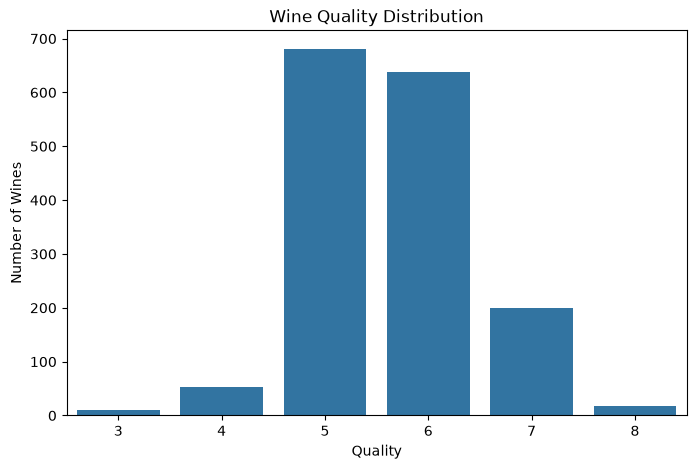

In [11]:
# Visualize the distribution of the original wine quality scores

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")

plt.show()

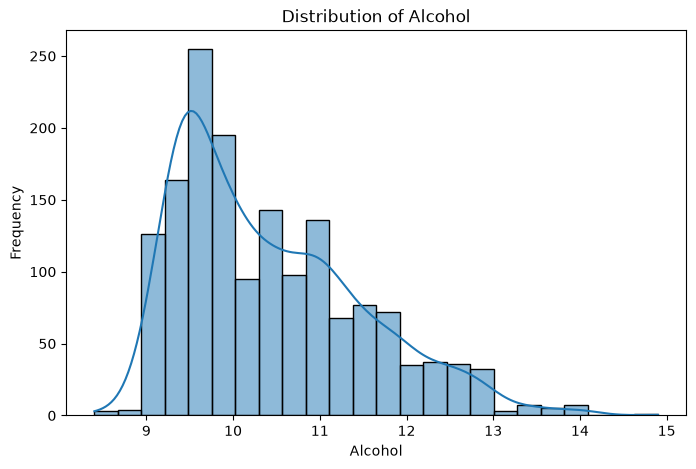

In [12]:
# Visualize the distribution of alcohol content

plt.figure(figsize=(8, 5))

sns.histplot(df["alcohol"], kde=True)

plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")

plt.show()

## 4. Data Cleaning

Remove duplicate records before continuing with analysis and modeling.

In [13]:
# Remove duplicate rows so repeated records do not affect the analysis

df = df.drop_duplicates()

In [14]:
# Check the dataset size after removing duplicates

df.shape


(1359, 12)

In [15]:
# Confirm that duplicate rows have been removed

df.duplicated().sum()

np.int64(0)

## 5. Target Variable Creation

Convert the original quality score into a binary classification problem: **Good** (quality ≥ 6) and **Bad** (quality < 6).

In [16]:
# Convert the original quality score into two classes: Good and Bad

df["quality_label"] = df["quality"].apply(
    lambda x: "Good" if x >= 6 else "Bad"
)

In [17]:
# Compare the original quality score with the new binary label

df[["quality", "quality_label"]].head(10)

,quality,quality_label
0,5,Bad
1,5,Bad
2,5,Bad
3,6,Good
5,5,Bad
6,5,Bad
7,7,Good
8,7,Good
9,5,Bad
10,5,Bad


In [18]:
# Count the number of Good and Bad wines

df["quality_label"].value_counts()

quality_label
Good    719
Bad     640
Name: count, dtype: int64

In [19]:
# Calculate the percentage of Good and Bad wines

df["quality_label"].value_counts(normalize=True) * 100

quality_label
Good    52.906549
Bad     47.093451
Name: proportion, dtype: float64

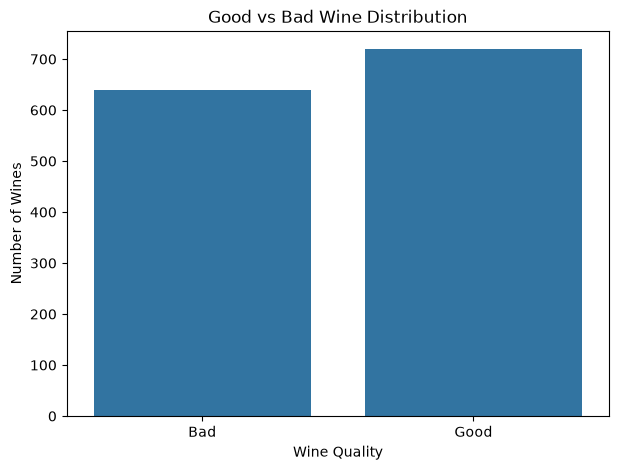

In [20]:
# Visualize the balance between Good and Bad wine classes

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="quality_label")

plt.title("Good vs Bad Wine Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.show()

## 6. Exploratory Data Analysis (EDA)

Analyze numerical features, class-wise differences, outliers, correlations, and useful visual patterns.

In [21]:
# Generate descriptive statistics for the numerical features

df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [22]:
# Calculate the average value of each feature for Good and Bad wines

df.groupby("quality_label").mean(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality_label,,,,,,,,,,,,
Bad,8.141719,0.592930,0.237547,2.526797,0.094144,16.659375,55.146094,0.997044,3.309016,0.620484,9.920781,4.885937
Good,8.460918,0.472997,0.303296,2.520376,0.082765,15.211405,39.420028,0.996411,3.310473,0.692726,10.887645,6.279555


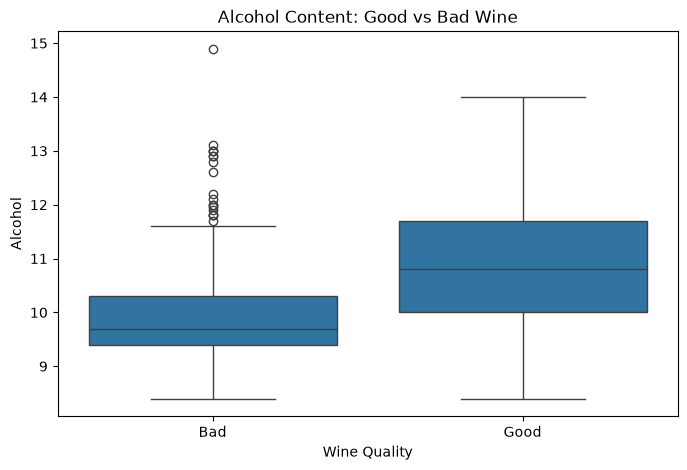

In [23]:
# Compare alcohol content between Good and Bad wines using boxplots

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="quality_label", y="alcohol")

plt.title("Alcohol Content: Good vs Bad Wine")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")

plt.show()

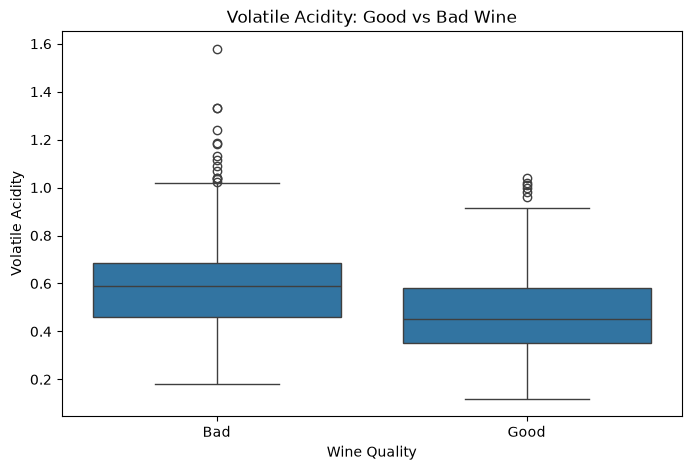

In [24]:
# Compare volatile acidity between Good and Bad wines using boxplots

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="quality_label", y="volatile acidity")

plt.title("Volatile Acidity: Good vs Bad Wine")
plt.xlabel("Wine Quality")
plt.ylabel("Volatile Acidity")

plt.show()

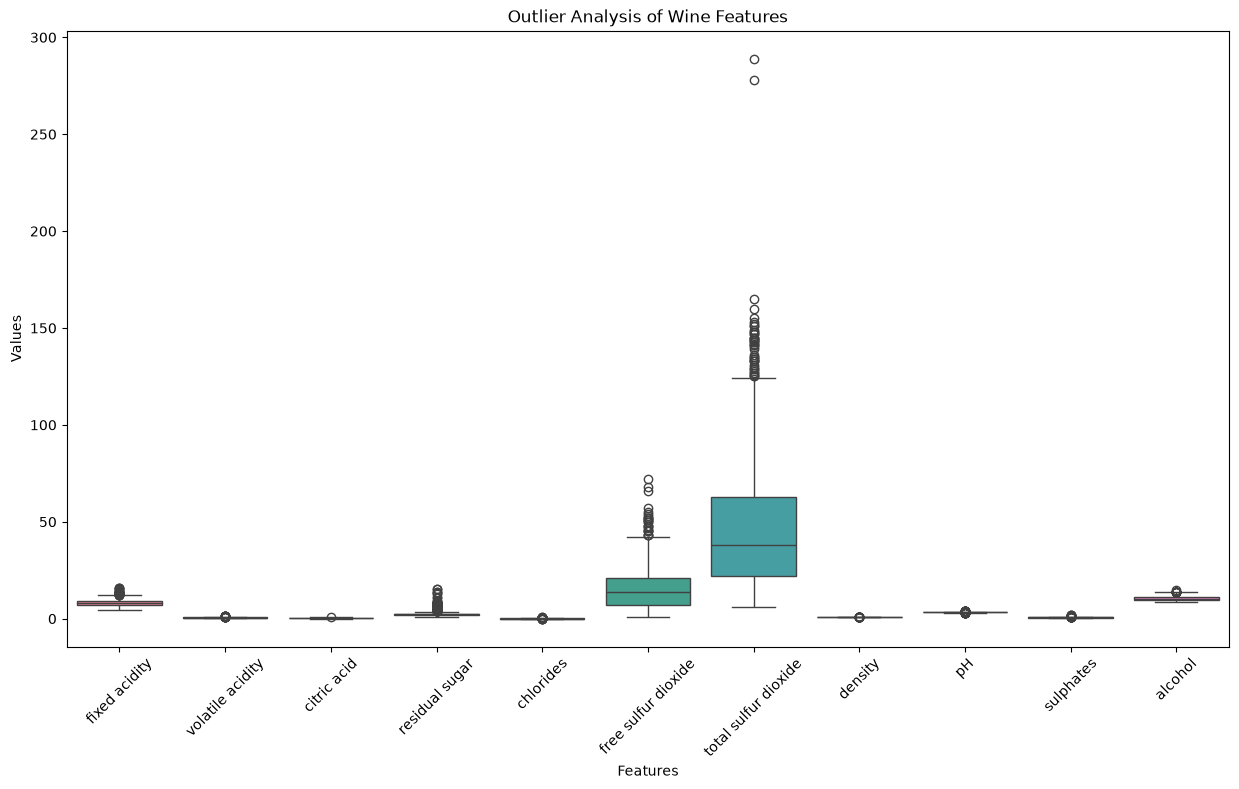

In [25]:
# Inspect the numerical features for possible outliers


plt.figure(figsize=(15, 8))

sns.boxplot(data=df.drop(columns=["quality", "quality_label"]))

plt.xticks(rotation=45)
plt.title("Outlier Analysis of Wine Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

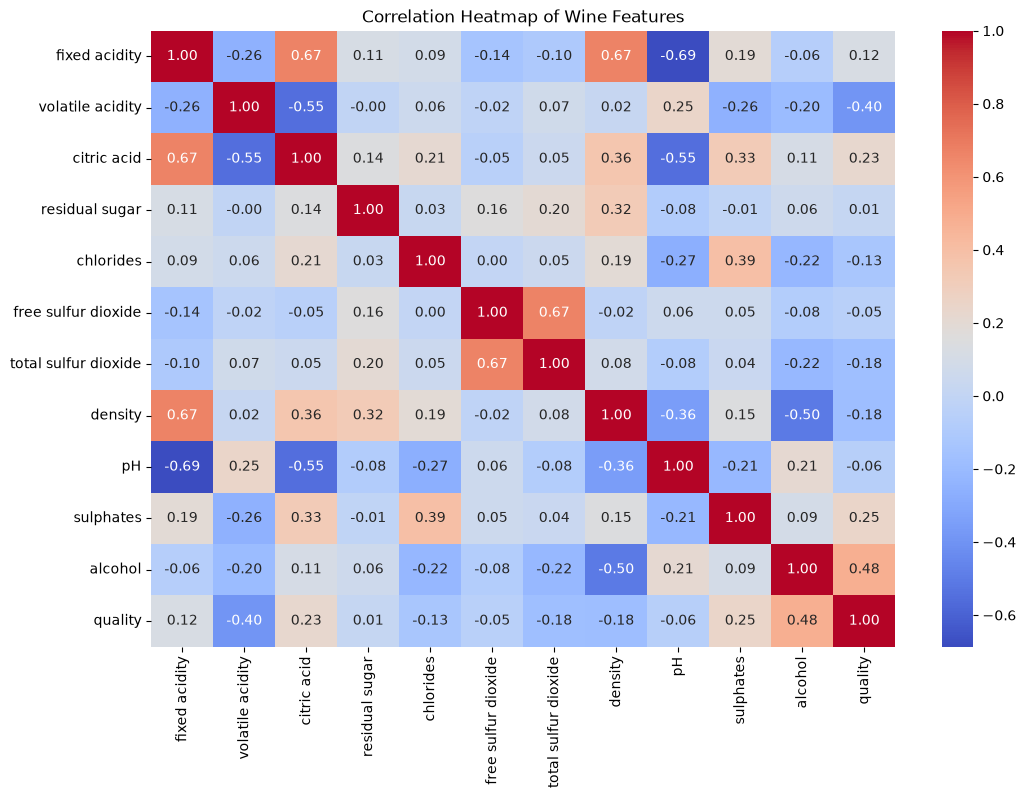

In [26]:
# Calculate and visualize correlations between numerical features

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.drop(columns=["quality_label"]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Wine Features")

plt.show()

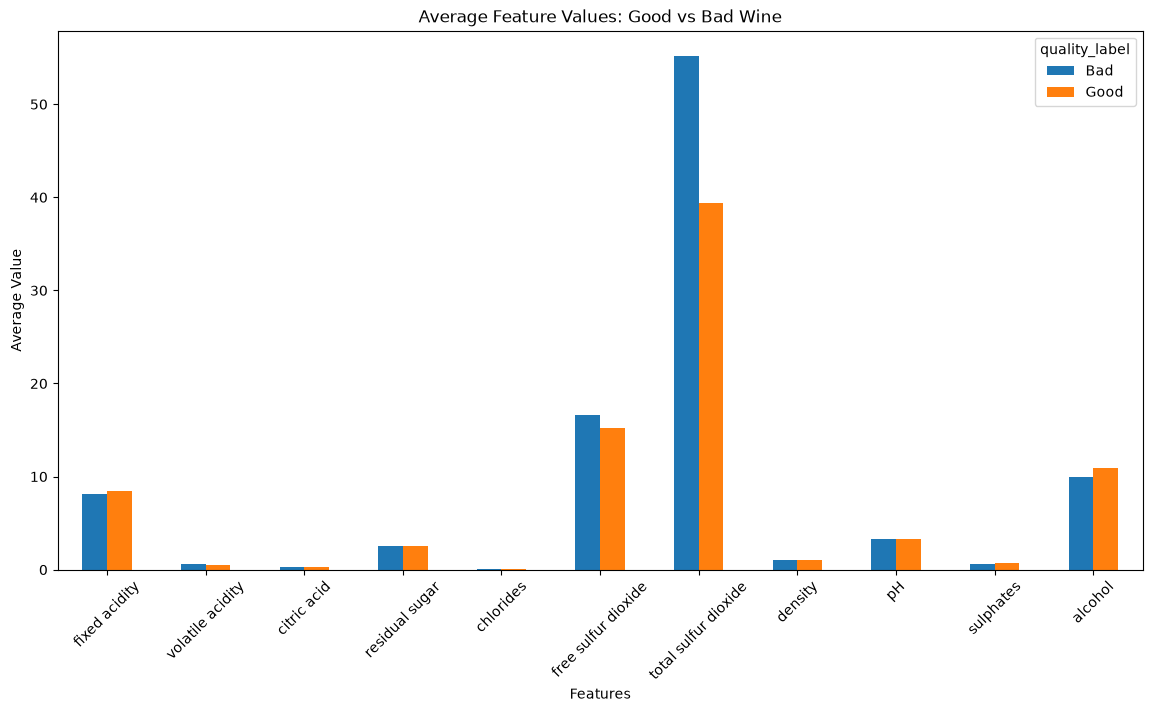

In [27]:
# Compare average feature values between Good and Bad wines

feature_means = df.groupby("quality_label").mean(numeric_only=True)

feature_means.drop(columns=["quality"]).T.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Average Feature Values: Good vs Bad Wine")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.show()

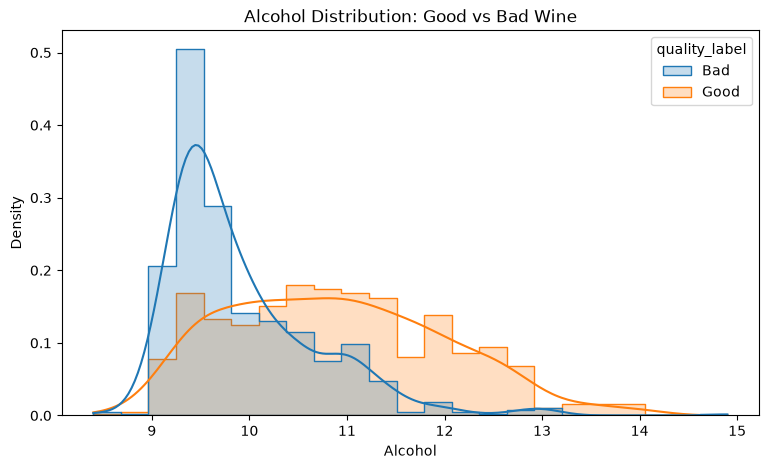

In [28]:
# Compare the alcohol distributions of Good and Bad wines

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="alcohol",
    hue="quality_label",
    kde=True,
    element="step",
    stat="density"
)

plt.title("Alcohol Distribution: Good vs Bad Wine")
plt.xlabel("Alcohol")
plt.ylabel("Density")

plt.show()

## 7. Prepare Data for Modeling

Separate features and target, encode the target labels, and create training and testing sets.

In [29]:
# Separate input features (X) from the target variable (y)

X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

In [30]:
# Convert class labels from text to numbers: Bad=0 and Good=1

y = y.map({"Bad": 0, "Good": 1})

y.value_counts()

quality_label
1    719
0    640
Name: count, dtype: int64

In [31]:
# Split the data into training and testing sets while preserving class proportions

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
# Check the sizes and class distributions of the training and testing sets

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training data: (1087, 11)
Testing data: (272, 11)

Training labels:
quality_label
1    575
0    512
Name: count, dtype: int64

Testing labels:
quality_label
1    144
0    128
Name: count, dtype: int64


## 8. Gaussian Naive Bayes: Required Statistics

Gaussian Naive Bayes models each feature using its class-wise **mean**, **variance**, and **prior probability**.

In [33]:
# Separate training samples into Good and Bad classes

X_train_good = X_train[y_train == 1]
X_train_bad = X_train[y_train == 0]

In [34]:
# Display the number of Good and Bad training samples

print("Good training samples:", X_train_good.shape)
print("Bad training samples:", X_train_bad.shape)

Good training samples: (575, 11)
Bad training samples: (512, 11)


In [35]:
# Calculate the mean and variance of every feature for Good wines

good_mean = X_train_good.mean()
good_variance = X_train_good.var()

In [36]:
# Calculate the mean and variance of every feature for Bad wines

bad_mean = X_train_bad.mean()
bad_variance = X_train_bad.var()

In [37]:
# Combine class-wise means and variances into one table

stats = pd.DataFrame({
    "Good Mean": good_mean,
    "Good Variance": good_variance,
    "Bad Mean": bad_mean,
    "Bad Variance": bad_variance
})

stats

,Good Mean,Good Variance,Bad Mean,Bad Variance
fixed acidity,8.486957,3.562147,8.102734,2.409190
volatile acidity,0.478148,0.027691,0.590410,0.034334
citric acid,0.303826,0.040968,0.238477,0.034317
residual sugar,2.546261,1.916881,2.545703,1.964052
chlorides,0.083016,0.001651,0.094324,0.003582
free sulfur dioxide,14.985217,95.771123,16.765625,119.189579
total sulfur dioxide,38.966957,803.795073,55.463867,1407.798594
density,0.996424,0.000004,0.997045,0.000003
pH,3.309774,0.024662,3.314063,0.022300
sulphates,0.693739,0.025177,0.619668,0.032705


In [38]:
# Calculate prior probability for each wine class

prior_good = (y_train == 1).mean()
prior_bad = (y_train == 0).mean()

print("Prior Good:", prior_good)
print("Prior Bad:", prior_bad)

Prior Good: 0.5289788408463661
Prior Bad: 0.47102115915363385


## 9. Gaussian Probability Calculation

Use the Gaussian probability density function to calculate how likely a feature value is under each class.

In [39]:
# Define the Gaussian probability density function used by Gaussian Naive Bayes

def gaussian_pdf(x, mean, variance):
    return (1 / np.sqrt(2 * np.pi * variance)) * np.exp(
        -((x - mean) ** 2) / (2 * variance)
    )

In [40]:
# Calculate the alcohol likelihood for a hypothetical wine in each class

x = 11.2

good_likelihood = gaussian_pdf(
    x,
    good_mean["alcohol"],
    good_variance["alcohol"]
)

bad_likelihood = gaussian_pdf(
    x,
    bad_mean["alcohol"],
    bad_variance["alcohol"]
)

print("Good likelihood:", good_likelihood)
print("Bad likelihood:", bad_likelihood)

Good likelihood: 0.3474023210339306
Bad likelihood: 0.132624775312823


In [41]:
# Multiply likelihood by prior to obtain the class score

score_good = prior_good * good_likelihood
score_bad = prior_bad * bad_likelihood

print("Good score:", score_good)
print("Bad score:", score_bad)

Good score: 0.18376847708786578
Bad score: 0.062469075400336124


In [42]:
# Choose the class with the larger score

if score_good > score_bad:
    print("Prediction: Good")
else:
    print("Prediction: Bad")

Prediction: Good


## 10. Gaussian Naive Bayes From Scratch

Now implement the core calculations using only Python and NumPy, without using a ready-made Naive Bayes classifier.

In [43]:
# Convert pandas data into NumPy arrays for the from-scratch implementation

import numpy as np

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

print("X_train shape:", X_train_np.shape)
print("y_train shape:", y_train_np.shape)

X_train shape: (1087, 11)
y_train shape: (1087,)


In [44]:
# Find the unique class labels present in the training data

classes = np.unique(y_train_np)

print("Classes:", classes)

Classes: [0 1]


In [45]:
# Select training samples for each class using NumPy

X_good = X_train_np[y_train_np == 1]
X_bad = X_train_np[y_train_np == 0]

print("Good shape:", X_good.shape)
print("Bad shape:", X_bad.shape)

Good shape: (575, 11)
Bad shape: (512, 11)


In [46]:
# Calculate class-wise feature means from scratch using NumPy

good_mean_np = np.mean(X_good, axis=0)
bad_mean_np = np.mean(X_bad, axis=0)

print("Good means:")
print(good_mean_np)

print("\nBad means:")
print(bad_mean_np)

Good means:
[ 8.48695652  0.47814783  0.30382609  2.54626087  0.08301565 14.98521739
 38.96695652  0.99642417  3.30977391  0.69373913 10.90715942]

Bad means:
[ 8.10273437  0.59041016  0.23847656  2.54570312  0.09432422 16.765625
 55.46386719  0.99704451  3.3140625   0.61966797  9.91992187]


In [47]:
# Calculate class-wise feature variances from scratch using NumPy

good_variance_np = np.var(X_good, axis=0)
bad_variance_np = np.var(X_bad, axis=0)

print("Good variances:")
print(good_variance_np)

print("\nBad variances:")
print(bad_variance_np)

Good variances:
[3.55595161e+00 2.76429608e-02 4.08970132e-02 1.91354689e+00
 1.64810236e-03 9.56045641e+01 8.02397169e+02 4.15631023e-06
 2.46189054e-02 2.51333233e-02 1.22777145e+00]

Bad variances:
[2.40448471e+00 3.42673122e-02 3.42504135e-02 1.96021591e+00
 3.57458238e-03 1.18956787e+02 1.40504899e+03 2.57686695e-06
 2.22569336e-02 3.26407101e-02 6.04993744e-01]


In [48]:
# Calculate class prior probabilities from the training labels

prior_good_np = np.mean(y_train_np == 1)
prior_bad_np = np.mean(y_train_np == 0)

print("Good prior:", prior_good_np)
print("Bad prior:", prior_bad_np)

Good prior: 0.5289788408463661
Bad prior: 0.47102115915363385


In [49]:
# Select the first test wine as an example for manual prediction

x_new = X_test.iloc[0].to_numpy()

print(x_new)

[10.4      0.44     0.42     1.5      0.145   34.      48.       0.99832
  3.38     0.86     9.9    ]


In [50]:
# Calculate a Gaussian likelihood for every feature for both classes

good_likelihoods = gaussian_pdf(
    x_new,
    good_mean_np,
    good_variance_np
)

bad_likelihoods = gaussian_pdf(
    x_new,
    bad_mean_np,
    bad_variance_np
)

print("Good likelihoods:")
print(good_likelihoods)

print("\nBad likelihoods:")
print(bad_likelihoods)

Good likelihoods:
[1.26458277e-01 2.33714752e+00 1.67264489e+00 2.16655375e-01
 3.06340144e+00 6.15818640e-03 1.33854705e-02 1.26992676e+02
 2.30025705e+00 1.45196958e+00 2.38202791e-01]

Bad likelihoods:
[8.58614667e-02 1.54920841e+00 1.33250766e+00 2.15587605e-01
 4.65902995e+00 1.04958987e-02 1.04340900e-02 1.81247103e+02
 2.42526408e+00 9.11541803e-01 5.12734067e-01]


In [51]:
# Multiply the individual feature likelihoods to obtain overall likelihoods

good_likelihood = np.prod(good_likelihoods)
bad_likelihood = np.prod(bad_likelihoods)

print("Overall Good likelihood:", good_likelihood)
print("Overall Bad likelihood:", bad_likelihood)

Overall Good likelihood: 0.0027324762590610193
Overall Bad likelihood: 0.004005624494292666


In [52]:
# Multiply overall likelihood by the class prior to obtain class scores

good_score = prior_good_np * good_likelihood
bad_score = prior_bad_np * bad_likelihood

print("Good score:", good_score)
print("Bad score:", bad_score)

Good score: 0.001445422124158313
Bad score: 0.00188673389243592


In [53]:
# Predict the class with the larger probability score

if good_score > bad_score:
    print("Prediction: Good")
else:
    print("Prediction: Bad")

Prediction: Bad


In [54]:
# Use log probabilities to avoid numerical underflow when multiplying many small values

good_log_score = np.log(prior_good_np) + np.sum(
    np.log(good_likelihoods)
)

bad_log_score = np.log(prior_bad_np) + np.sum(
    np.log(bad_likelihoods)
)

print("Good log score:", good_log_score)
print("Bad log score:", bad_log_score)

Good log score: -6.539353872633457
Bad log score: -6.272908044036787


In [55]:
# Choose the class with the larger log score

if good_log_score > bad_log_score:
    print("Prediction: Good")
else:
    print("Prediction: Bad")

Prediction: Bad


## 11. Complete From-Scratch Model

Create the Gaussian Naive Bayes class with training and prediction functionality.

In [ ]:
# Implement Gaussian Naive Bayes without using a ready-made ML classifier

class GaussianNBFromScratch:

    def __init__(self, var_smoothing=1e-9):
        # Store the smoothing value used to avoid numerical instability
        self.var_smoothing = var_smoothing

    def fit(self, X, y):

        # Convert input features and target into NumPy arrays
        X = np.asarray(X)
        y = np.asarray(y)

        # Find all unique class labels
        self.classes = np.unique(y)

        # Create lists to store class-wise means, variances, and priors
        self.means = []
        self.variances = []
        self.priors = []

        # Calculate statistics separately for each class
        for c in self.classes:

            # Select only the samples belonging to the current class
            X_c = X[y == c]

            # Calculate the mean of every feature for the current class
            mean = np.mean(X_c, axis=0)

            # Calculate the variance of every feature for the current class
            variance = np.var(X_c, axis=0)

            # Calculate the prior probability of the current class
            prior = len(X_c) / len(X)

            # Store the calculated values
            self.means.append(mean)
            self.variances.append(variance)
            self.priors.append(prior)

        # Convert the lists into NumPy arrays for easier calculations
        self.means = np.array(self.means)
        self.variances = np.array(self.variances)
        self.priors = np.array(self.priors)

        # Add a small value to the variance for numerical stability
        epsilon = self.var_smoothing * np.max(
            np.var(X, axis=0)
        )

        # Add the smoothing value to all feature variances
        self.variances += epsilon

        # Return the trained model
        return self

    def gaussian_pdf(self, X, mean, variance):

        # Calculate the Gaussian probability density for the given feature values
        return (
            1 / np.sqrt(2 * np.pi * variance)
        ) * np.exp(
            -((X - mean) ** 2) / (2 * variance)
        )

    def predict(self, X):

        # Convert input data into a NumPy array
        X = np.asarray(X)

        # Create a list to store the predicted classes
        predictions = []

        # Process each test sample one by one
        for x in X:

            # Store the log probability score for each class
            log_scores = []

            # Calculate the score for every possible class
            for i, c in enumerate(self.classes):

                # Calculate the likelihood of every feature for this class
                likelihoods = self.gaussian_pdf(
                    x,
                    self.means[i],
                    self.variances[i]
                )

                # Calculate the log of the posterior score
                # Log probabilities help prevent numerical underflow
                log_score = (
                    np.log(self.priors[i])
                    + np.sum(np.log(likelihoods))
                )

                # Store the score of the current class
                log_scores.append(log_score)

            # Select the class having the highest log score
            predictions.append(
                self.classes[np.argmax(log_scores)]
            )

        # Convert the predictions list into a NumPy array
        return np.array(predictions)

In [57]:
# Create and train the from-scratch Gaussian Naive Bayes model

model = GaussianNBFromScratch()
model.fit(X_train_np, y_train_np)
print("Model trained successfully!")

Model trained successfully!


In [58]:
# Generate predictions for the test dataset using the from-scratch model

y_pred_scratch = model.predict(X_test.to_numpy())                       

print("First 20 predictions:")                                    
print(y_pred_scratch[:20])                                            

First 20 predictions:
[0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1]


In [59]:
# Compare the first 20 actual labels with the model predictions

print("Actual:")
print(y_test.to_numpy()[:20])

print("\nPredicted:")
print(y_pred_scratch[:20])                                          

Actual:
[0 0 0 0 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1]

Predicted:
[0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1]


## 12. Evaluate the From-Scratch Model

Measure accuracy, precision, recall, F1 score, and inspect the confusion matrix.

In [60]:
# Calculate the accuracy of the from-scratch model

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred_scratch
)

print("Accuracy:", accuracy)

Accuracy: 0.7242647058823529


In [61]:
# Calculate precision, recall, and F1 score for the from-scratch model

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(y_test, y_pred_scratch)
recall = recall_score(y_test, y_pred_scratch)
f1 = f1_score(y_test, y_pred_scratch)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7633587786259542
Recall: 0.6944444444444444
F1 Score: 0.7272727272727273


In [62]:
# Generate the confusion matrix for the from-scratch model

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_scratch)

print(cm)

[[ 97  31]
 [ 44 100]]


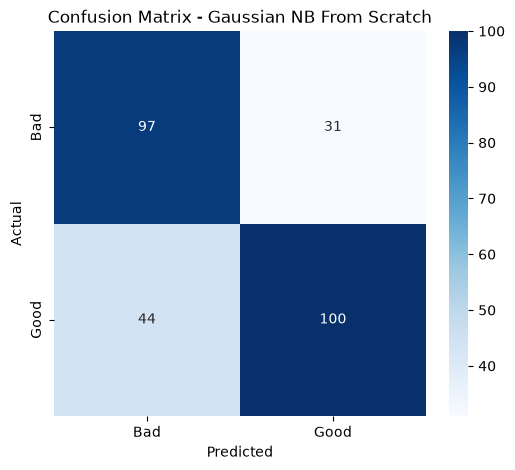

In [63]:
# Visualize the confusion matrix to understand correct and incorrect predictions

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad", "Good"],
    yticklabels=["Bad", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian NB From Scratch")

plt.show()

## 13. Gaussian Naive Bayes Using Scikit-learn

Train the same type of model using Scikit-learn so that its results can be compared with the from-scratch implementation.

In [64]:
# Import the Scikit-learn Gaussian Naive Bayes implementation for comparison

from sklearn.naive_bayes import GaussianNB

In [65]:
# Create and train the Scikit-learn Gaussian Naive Bayes model

sklearn_model = GaussianNB()

sklearn_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[512.,575.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.47,0.53]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.154e-06
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 11)","[[ 8.1 , 0.59, 0.24,..., 3.31, 0.62, 9.92], [ 8.49, 0.48, 0.3 ,..., 3.31, 0.69,10.91]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 11)","[[2.4 ,0.03,0.03,...,0.02,0.03,0.6 ], [3.56,0.03,0.04,...,0.02,0.03,1.23]]"


In [66]:
# Generate predictions using the Scikit-learn model

y_pred_sklearn = sklearn_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_sklearn[:20])

First 20 predictions:
[0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1]


In [67]:
# Calculate evaluation metrics for the Scikit-learn model

accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
precision_sklearn = precision_score(y_test, y_pred_sklearn)
recall_sklearn = recall_score(y_test, y_pred_sklearn)
f1_sklearn = f1_score(y_test, y_pred_sklearn)

print("Accuracy:", accuracy_sklearn)
print("Precision:", precision_sklearn)
print("Recall:", recall_sklearn)
print("F1 Score:", f1_sklearn)

Accuracy: 0.7242647058823529
Precision: 0.7633587786259542
Recall: 0.6944444444444444
F1 Score: 0.7272727272727273


In [68]:
# Measure how often the two implementations make the same prediction

agreement = np.mean(
    y_pred_scratch == y_pred_sklearn
)

print("Prediction Agreement:", agreement)
print("Prediction Agreement (%):", agreement * 100)

Prediction Agreement: 1.0
Prediction Agreement (%): 100.0


## 14. From-Scratch vs Scikit-learn Comparison

Compare evaluation metrics and prediction agreement between the two implementations.

In [69]:
# Create a side-by-side comparison of the evaluation metrics

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "From Scratch": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Scikit-learn": [
        accuracy_sklearn,
        precision_sklearn,
        recall_sklearn,
        f1_sklearn
    ]
})

comparison["Difference"] = (
    comparison["From Scratch"] -
    comparison["Scikit-learn"]
)

comparison

,Metric,From Scratch,Scikit-learn,Difference
0,Accuracy,0.724265,0.724265,0.0
1,Precision,0.763359,0.763359,0.0
2,Recall,0.694444,0.694444,0.0
3,F1 Score,0.727273,0.727273,0.0


In [70]:
# Count exactly how many test predictions are identical between both models

correct_agreement = np.sum(
    y_pred_scratch == y_pred_sklearn
)

total_predictions = len(y_test)

print("Same predictions:", correct_agreement)
print("Total predictions:", total_predictions)
print("Agreement:", correct_agreement / total_predictions)

Same predictions: 272
Total predictions: 272
Agreement: 1.0


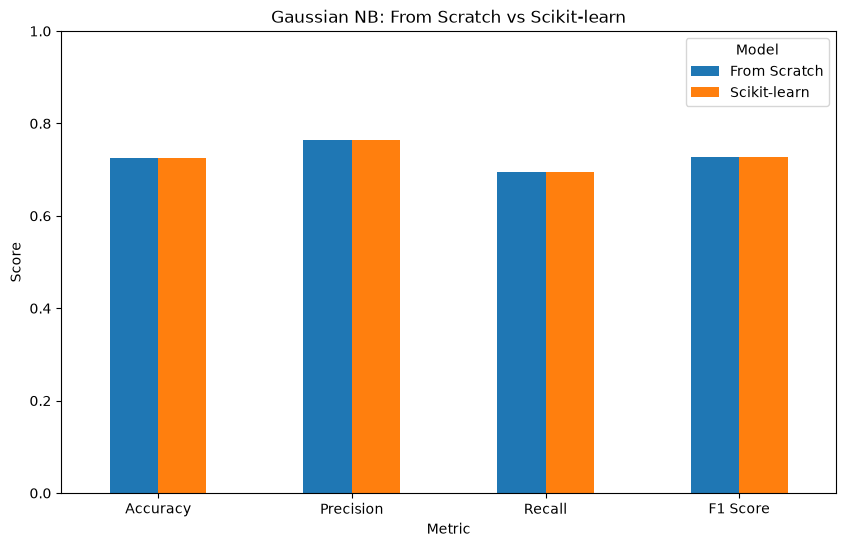

In [71]:
# Visualize the performance comparison between both implementations

comparison_plot = comparison.set_index("Metric")[
    ["From Scratch", "Scikit-learn"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Gaussian NB: From Scratch vs Scikit-learn")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")

plt.show()

## 15. Error Analysis

Analyze where the model makes correct and incorrect predictions.

In [72]:
# Create a table containing actual labels, predicted labels, and prediction results

error_analysis = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred_scratch
})

error_analysis["Result"] = np.where(
    error_analysis["Actual"] == error_analysis["Predicted"],
    "Correct",
    "Incorrect"
)

error_analysis["Actual Label"] = error_analysis["Actual"].map({
    0: "Bad",
    1: "Good"
})

error_analysis["Predicted Label"] = error_analysis["Predicted"].map({
    0: "Bad",
    1: "Good"
})

error_analysis.head()

,Actual,Predicted,Result,Actual Label,Predicted Label
0,0,0,Correct,Bad,Bad
1,0,0,Correct,Bad,Bad
2,0,1,Incorrect,Bad,Good
3,0,0,Correct,Bad,Bad
4,1,1,Correct,Good,Good


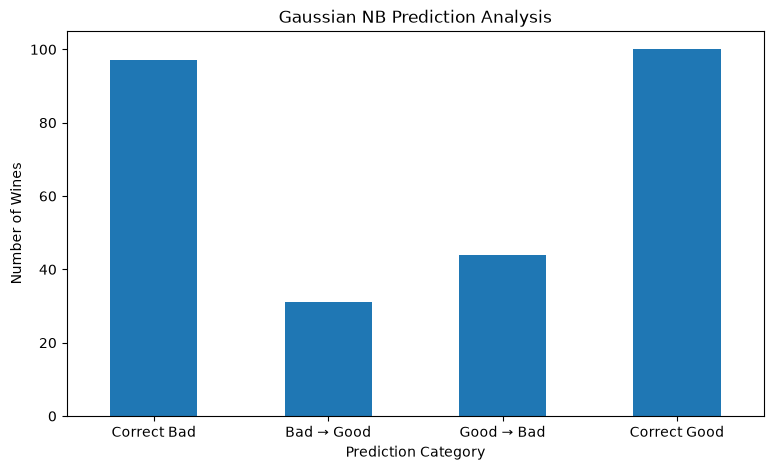

In [73]:
# Break the confusion matrix into correct and incorrect prediction categories

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_scratch
).ravel()

error_counts = pd.Series({
    "Correct Bad": tn,
    "Bad → Good": fp,
    "Good → Bad": fn,
    "Correct Good": tp
})

plt.figure(figsize=(9, 5))

error_counts.plot(kind="bar")

plt.title("Gaussian NB Prediction Analysis")
plt.xlabel("Prediction Category")
plt.ylabel("Number of Wines")
plt.xticks(rotation=0)

plt.show()

## 16. Gaussian Naive Bayes - Conclusion

Gaussian Naive Bayes was implemented from scratch using NumPy on the Wine Quality Red dataset.

The dataset was converted into a binary classification problem:
- Quality >= 6 → Good
- Quality < 6 → Bad

The from-scratch implementation achieved:
- Accuracy: 72.43%
- Precision: 76.34%
- Recall: 69.44%
- F1 Score: 72.73%

The implementation was also compared with Scikit-learn's GaussianNB model. Both models produced identical predictions on all 272 test samples, resulting in 100% prediction agreement.

This confirms that the from-scratch implementation correctly follows the Gaussian Naive Bayes algorithm.

## 17. Hyperparameter: var_smoothing

The `var_smoothing` parameter is used to improve numerical stability
in Gaussian Naive Bayes.

A small value is added to the feature variances so that extremely
small or zero variances do not cause numerical problems.

In this project, the value used is:

var_smoothing = 1e-9

The same value is also used in Scikit-learn's GaussianNB model,
which helps make the comparison consistent.

## 18. Applications

Gaussian Naive Bayes can be used for:

- Classification of continuous numerical data
- Medical diagnosis
- Sensor and measurement classification
- Financial data classification
- Quality classification
- Scientific data analysis
- Basic real-world classification problems